# 02. Baseline Models for OOS Detection

**Цель:** Установить нижнюю границу качества для OOS-детекции.

## Baselines
1. **TF-IDF + Logistic Regression** (argmax / threshold)
2. **Cosine Similarity** с BERT, MiniLM и E5-Large-Instruct (argmax / threshold)

## Режим
- **Few-shot (10 примеров на класс)** для быстрой итерации
- Val и test всегда полные (для стабильной калибровки порога)

## 1. Setup

In [1]:
import sys
import json
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Project paths
NOTEBOOK_DIR = Path.cwd()
TASK_DIR = NOTEBOOK_DIR.parent
PROJECT_ROOT = TASK_DIR.parent.parent
DATA_DIR = TASK_DIR / "data" / "processed"
RESULTS_DIR = TASK_DIR / "results"
CACHE_DIR = DATA_DIR / "embeddings_cache"

sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")
print(f"Cache dir: {CACHE_DIR}")

Project root: /Users/anastasiagapeeva/Documents/Education/AITH/ProjectPractice2/autoguardrails
Cache dir: /Users/anastasiagapeeva/Documents/Education/AITH/ProjectPractice2/autoguardrails/tasks/oos_detection/data/processed/embeddings_cache


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from shared.data_utils import load_clinc150, load_fewshot
from shared.evaluation import Evaluator
from shared.metrics import f1_oos
from baselines.tfidf_logreg import TfidfLogreg
from baselines.embedding_threshold import EmbeddingThreshold

print("Imports successful!")

Imports successful!


## 2. Load Data

In [3]:
# Few-shot settings
N_SHOTS = 10
SEED = 42
MODE_STR = f"{N_SHOTS}shot"

# Train depends on mode (few-shot)
train_data = load_fewshot(N_SHOTS, SEED, DATA_DIR)

# Val and test are ALWAYS full
val_data = load_clinc150("validation", DATA_DIR)
test_data = load_clinc150("test", DATA_DIR)

print(f"Train: {len(train_data['texts'])} samples (few-shot)")
print(f"Val: {len(val_data['texts'])} samples (full)")
print(f"Test: {len(test_data['texts'])} samples (full)")

Train: 1650 samples (few-shot)
Val: 3097 samples (full)
Test: 5498 samples (full)


In [4]:
evaluator = Evaluator(test_data, RESULTS_DIR)
results = []  # Store all results for comparison

## 3. TF-IDF + Logistic Regression

In [5]:
# Train TF-IDF model
print("Training TF-IDF + LogReg...")
tfidf_model = TfidfLogreg()
tfidf_model.fit(train_data['texts'], train_data['labels'])
print("Training complete!")

Training TF-IDF + LogReg...
Training complete!


In [6]:
# Evaluate argmax variant (no threshold)
print("Evaluating tfidf_argmax...")
tfidf_argmax_result = evaluator.evaluate(
    model=tfidf_model,
    model_name="tfidf_argmax",
    mode=MODE_STR,
    n_shots=N_SHOTS,
    seed=SEED,
)
results.append(tfidf_argmax_result.to_dict())

print(f"\nTF-IDF Argmax Results:")
print(f"  OOS Recall:     {tfidf_argmax_result.oos_recall:.4f}")
print(f"  In-Domain Acc:  {tfidf_argmax_result.in_domain_acc:.4f}")
print(f"  F1 OOS:         {tfidf_argmax_result.f1_oos:.4f}")
print(f"  AUROC:          {tfidf_argmax_result.auroc:.4f}")

Evaluating tfidf_argmax...

TF-IDF Argmax Results:
  OOS Recall:     0.0010
  In-Domain Acc:  0.7434
  F1 OOS:         0.0020
  AUROC:          0.7683


### Threshold Calibration (TF-IDF)

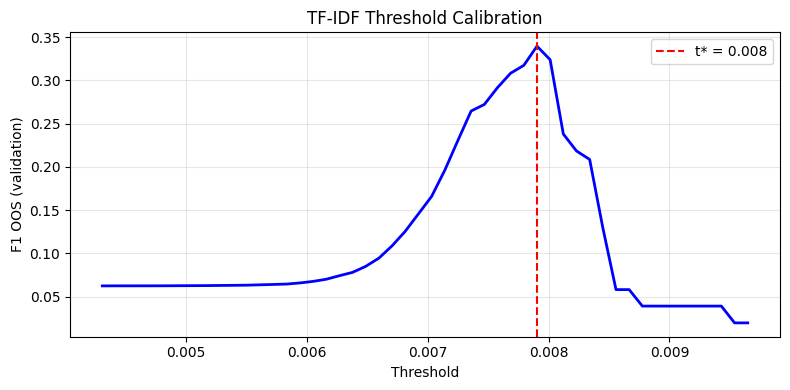

Optimal threshold: 0.0079
F1 OOS at t*: 0.3396


In [7]:
# Visualize threshold calibration
val_texts = val_data["texts"]
val_labels = np.array(val_data["labels"])

oos_scores_val = tfidf_model.predict_proba(val_texts)
proba_val = tfidf_model.pipeline.predict_proba(val_texts)
classes = tfidf_model.pipeline.named_steps["clf"].classes_

thresholds = np.linspace(oos_scores_val.min(), oos_scores_val.max(), 50)
f1_vals = []

for t in thresholds:
    y_pred = tfidf_model._predict_with_threshold(oos_scores_val, proba_val, classes, t)
    f1_vals.append(f1_oos(val_labels, y_pred))

t_star = thresholds[np.argmax(f1_vals)]

plt.figure(figsize=(8, 4))
plt.plot(thresholds, f1_vals, 'b-', linewidth=2)
plt.axvline(t_star, color='red', linestyle='--', label=f't* = {t_star:.3f}')
plt.xlabel('Threshold')
plt.ylabel('F1 OOS (validation)')
plt.title('TF-IDF Threshold Calibration')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Optimal threshold: {t_star:.4f}")
print(f"F1 OOS at t*: {max(f1_vals):.4f}")

In [8]:
# Apply calibrated threshold
tfidf_model.calibrate_threshold(val_data['texts'], val_data['labels'])

tfidf_threshold_result = evaluator.evaluate(
    model=tfidf_model,
    model_name="tfidf_threshold",
    mode=MODE_STR,
    n_shots=N_SHOTS,
    seed=SEED,
)
results.append(tfidf_threshold_result.to_dict())

print(f"\nTF-IDF Threshold Results:")
print(f"  OOS Recall:     {tfidf_threshold_result.oos_recall:.4f}")
print(f"  In-Domain Acc:  {tfidf_threshold_result.in_domain_acc:.4f}")
print(f"  F1 OOS:         {tfidf_threshold_result.f1_oos:.4f}")
print(f"  AUROC:          {tfidf_threshold_result.auroc:.4f}")


TF-IDF Threshold Results:
  OOS Recall:     0.1330
  In-Domain Acc:  0.7370
  F1 OOS:         0.2254
  AUROC:          0.7683


## 4. Cosine Similarity (BERT)

In [9]:
print("Training Cosine Similarity (BERT)...")
cosine_bert = EmbeddingThreshold(model_name="bert-base-uncased", cache_dir=CACHE_DIR)
cosine_bert.fit(train_data['texts'], train_data['labels'])
print("Training complete!")

Training Cosine Similarity (BERT)...


No sentence-transformers model found with name bert-base-uncased. Creating a new one with mean pooling.


Training complete!


In [10]:
# Argmax variant
print("Evaluating cosine_bert_argmax...")
bert_argmax_result = evaluator.evaluate(
    model=cosine_bert,
    model_name="cosine_bert_argmax",
    mode=MODE_STR,
    n_shots=N_SHOTS,
    seed=SEED,
)
results.append(bert_argmax_result.to_dict())

print(f"\nCosine BERT Argmax Results:")
print(f"  OOS Recall:     {bert_argmax_result.oos_recall:.4f}")
print(f"  In-Domain Acc:  {bert_argmax_result.in_domain_acc:.4f}")
print(f"  F1 OOS:         {bert_argmax_result.f1_oos:.4f}")
print(f"  AUROC:          {bert_argmax_result.auroc:.4f}")

Evaluating cosine_bert_argmax...

Cosine BERT Argmax Results:
  OOS Recall:     0.9500
  In-Domain Acc:  0.3651
  F1 OOS:         0.4303
  AUROC:          0.8277


In [11]:
# Calibrate and evaluate threshold variant
t_star_bert = cosine_bert.calibrate_threshold(val_data['texts'], val_data['labels'])
print(f"Calibrated threshold (BERT): {t_star_bert:.4f}")

bert_threshold_result = evaluator.evaluate(
    model=cosine_bert,
    model_name="cosine_bert_threshold",
    mode=MODE_STR,
    n_shots=N_SHOTS,
    seed=SEED,
)
results.append(bert_threshold_result.to_dict())

print(f"\nCosine BERT Threshold Results:")
print(f"  OOS Recall:     {bert_threshold_result.oos_recall:.4f}")
print(f"  In-Domain Acc:  {bert_threshold_result.in_domain_acc:.4f}")
print(f"  F1 OOS:         {bert_threshold_result.f1_oos:.4f}")
print(f"  AUROC:          {bert_threshold_result.auroc:.4f}")

Calibrated threshold (BERT): 0.2506

Cosine BERT Threshold Results:
  OOS Recall:     0.3250
  In-Domain Acc:  0.6514
  F1 OOS:         0.4078
  AUROC:          0.8277


## 5. Cosine Similarity (MiniLM)

In [12]:
print("Training Cosine Similarity (MiniLM)...")
cosine_minilm = EmbeddingThreshold(model_name="sentence-transformers/all-MiniLM-L6-v2", cache_dir=CACHE_DIR)
cosine_minilm.fit(train_data['texts'], train_data['labels'])
print("Training complete!")

Training Cosine Similarity (MiniLM)...
Training complete!


In [13]:
# Argmax variant
print("Evaluating cosine_minilm_argmax...")
minilm_argmax_result = evaluator.evaluate(
    model=cosine_minilm,
    model_name="cosine_minilm_argmax",
    mode=MODE_STR,
    n_shots=N_SHOTS,
    seed=SEED,
)
results.append(minilm_argmax_result.to_dict())

print(f"\nCosine MiniLM Argmax Results:")
print(f"  OOS Recall:     {minilm_argmax_result.oos_recall:.4f}")
print(f"  In-Domain Acc:  {minilm_argmax_result.in_domain_acc:.4f}")
print(f"  F1 OOS:         {minilm_argmax_result.f1_oos:.4f}")
print(f"  AUROC:          {minilm_argmax_result.auroc:.4f}")

Evaluating cosine_minilm_argmax...

Cosine MiniLM Argmax Results:
  OOS Recall:     0.9990
  In-Domain Acc:  0.1999
  F1 OOS:         0.3573
  AUROC:          0.9447


In [14]:
# Calibrate and evaluate threshold variant
t_star_minilm = cosine_minilm.calibrate_threshold(val_data['texts'], val_data['labels'])
print(f"Calibrated threshold (MiniLM): {t_star_minilm:.4f}")

minilm_threshold_result = evaluator.evaluate(
    model=cosine_minilm,
    model_name="cosine_minilm_threshold",
    mode=MODE_STR,
    n_shots=N_SHOTS,
    seed=SEED,
)
results.append(minilm_threshold_result.to_dict())

print(f"\nCosine MiniLM Threshold Results:")
print(f"  OOS Recall:     {minilm_threshold_result.oos_recall:.4f}")
print(f"  In-Domain Acc:  {minilm_threshold_result.in_domain_acc:.4f}")
print(f"  F1 OOS:         {minilm_threshold_result.f1_oos:.4f}")
print(f"  AUROC:          {minilm_threshold_result.auroc:.4f}")

Calibrated threshold (MiniLM): 0.5931

Cosine MiniLM Threshold Results:
  OOS Recall:     0.5940
  In-Domain Acc:  0.8106
  F1 OOS:         0.6968
  AUROC:          0.9447


## 6. Cosine Similarity (E5-Large-Instruct)

Это тот же embedder, что использует AutoIntent (`intfloat/multilingual-e5-large-instruct`).
Сравнение покажет, сколько добавляет AutoML-оптимизация поверх простого cosine similarity.

In [15]:
print("Training Cosine Similarity (E5-Large-Instruct)...")
cosine_e5large = EmbeddingThreshold(model_name="intfloat/multilingual-e5-large-instruct", cache_dir=CACHE_DIR)
cosine_e5large.fit(train_data['texts'], train_data['labels'])
print("Training complete!")

Training Cosine Similarity (E5-Large-Instruct)...
Training complete!


In [16]:
# Argmax variant
print("Evaluating cosine_e5large_argmax...")
e5large_argmax_result = evaluator.evaluate(
    model=cosine_e5large,
    model_name="cosine_e5large_argmax",
    mode=MODE_STR,
    n_shots=N_SHOTS,
    seed=SEED,
)
results.append(e5large_argmax_result.to_dict())

print(f"\nCosine E5-Large Argmax Results:")
print(f"  OOS Recall:     {e5large_argmax_result.oos_recall:.4f}")
print(f"  In-Domain Acc:  {e5large_argmax_result.in_domain_acc:.4f}")
print(f"  F1 OOS:         {e5large_argmax_result.f1_oos:.4f}")
print(f"  AUROC:          {e5large_argmax_result.auroc:.4f}")

Evaluating cosine_e5large_argmax...

Cosine E5-Large Argmax Results:
  OOS Recall:     0.2810
  In-Domain Acc:  0.8666
  F1 OOS:         0.4333
  AUROC:          0.9411


In [17]:
# Calibrate and evaluate threshold variant
t_star_e5large = cosine_e5large.calibrate_threshold(val_data['texts'], val_data['labels'])
print(f"Calibrated threshold (E5-Large): {t_star_e5large:.4f}")

e5large_threshold_result = evaluator.evaluate(
    model=cosine_e5large,
    model_name="cosine_e5large_threshold",
    mode=MODE_STR,
    n_shots=N_SHOTS,
    seed=SEED,
)
results.append(e5large_threshold_result.to_dict())

print(f"\nCosine E5-Large Threshold Results:")
print(f"  OOS Recall:     {e5large_threshold_result.oos_recall:.4f}")
print(f"  In-Domain Acc:  {e5large_threshold_result.in_domain_acc:.4f}")
print(f"  F1 OOS:         {e5large_threshold_result.f1_oos:.4f}")
print(f"  AUROC:          {e5large_threshold_result.auroc:.4f}")

Calibrated threshold (E5-Large): 0.1328

Cosine E5-Large Threshold Results:
  OOS Recall:     0.5340
  In-Domain Acc:  0.8586
  F1 OOS:         0.6663
  AUROC:          0.9411


## 7. Results Comparison

In [18]:
# Create comparison table
df = pd.DataFrame(results)
df = df[['model_name', 'oos_recall', 'in_domain_acc', 'f1_oos', 'auroc', 'au_ioc', 'latency_ms']]
df = df.round(4)
df = df.sort_values('f1_oos', ascending=False)
df

,model_name,oos_recall,in_domain_acc,f1_oos,auroc,au_ioc,latency_ms
5,cosine_minilm_threshold,0.594,0.8106,0.6968,0.9447,0.7844,0.8059
7,cosine_e5large_threshold,0.534,0.8586,0.6663,0.9411,0.8222,1.5840
6,cosine_e5large_argmax,0.281,0.8666,0.4333,0.9411,0.8258,100.4166
2,cosine_bert_argmax,0.950,0.3651,0.4303,0.8277,0.3531,44.6045
3,cosine_bert_threshold,0.325,0.6514,0.4078,0.8277,0.5829,1.6706
4,cosine_minilm_argmax,0.999,0.1999,0.3573,0.9447,0.1966,8.5394
1,tfidf_threshold,0.133,0.7370,0.2254,0.7683,0.5852,2.5447
0,tfidf_argmax,0.001,0.7434,0.0020,0.7683,0.5859,1.2820


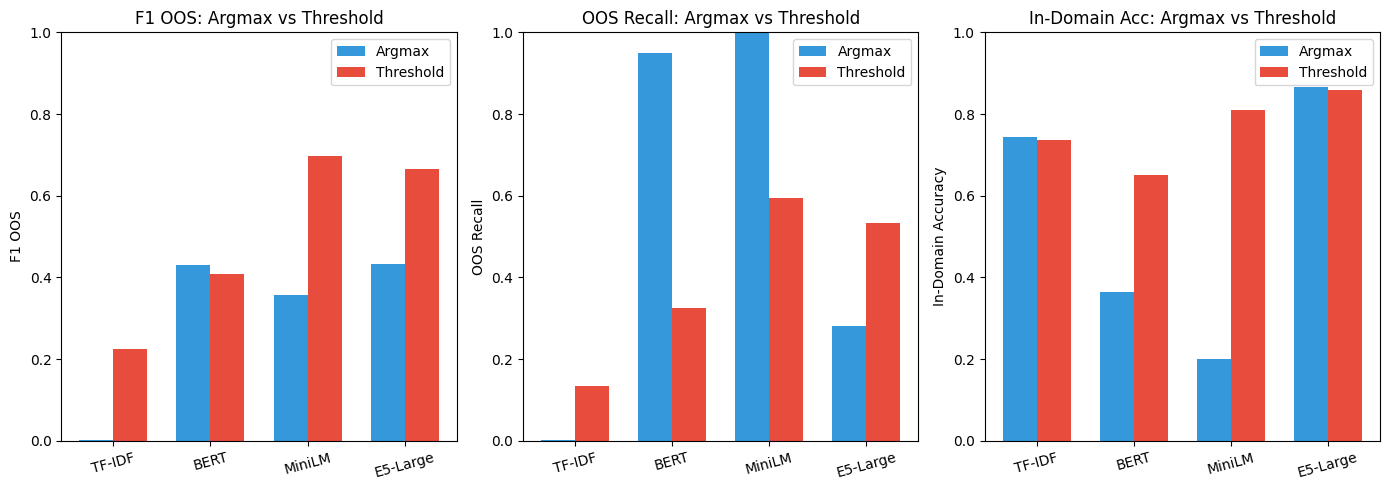

In [19]:
# Visualize argmax vs threshold comparison
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# Prepare data for grouped bar chart (4 models now)
models = ['TF-IDF', 'BERT', 'MiniLM', 'E5-Large']
argmax_f1 = [tfidf_argmax_result.f1_oos, bert_argmax_result.f1_oos, minilm_argmax_result.f1_oos, e5large_argmax_result.f1_oos]
thresh_f1 = [tfidf_threshold_result.f1_oos, bert_threshold_result.f1_oos, minilm_threshold_result.f1_oos, e5large_threshold_result.f1_oos]

argmax_recall = [tfidf_argmax_result.oos_recall, bert_argmax_result.oos_recall, minilm_argmax_result.oos_recall, e5large_argmax_result.oos_recall]
thresh_recall = [tfidf_threshold_result.oos_recall, bert_threshold_result.oos_recall, minilm_threshold_result.oos_recall, e5large_threshold_result.oos_recall]

argmax_acc = [tfidf_argmax_result.in_domain_acc, bert_argmax_result.in_domain_acc, minilm_argmax_result.in_domain_acc, e5large_argmax_result.in_domain_acc]
thresh_acc = [tfidf_threshold_result.in_domain_acc, bert_threshold_result.in_domain_acc, minilm_threshold_result.in_domain_acc, e5large_threshold_result.in_domain_acc]

x = np.arange(len(models))
width = 0.35

# F1 OOS
ax = axes[0]
ax.bar(x - width/2, argmax_f1, width, label='Argmax', color='#3498db')
ax.bar(x + width/2, thresh_f1, width, label='Threshold', color='#e74c3c')
ax.set_ylabel('F1 OOS')
ax.set_title('F1 OOS: Argmax vs Threshold')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15)
ax.legend()
ax.set_ylim(0, 1)

# OOS Recall
ax = axes[1]
ax.bar(x - width/2, argmax_recall, width, label='Argmax', color='#3498db')
ax.bar(x + width/2, thresh_recall, width, label='Threshold', color='#e74c3c')
ax.set_ylabel('OOS Recall')
ax.set_title('OOS Recall: Argmax vs Threshold')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15)
ax.legend()
ax.set_ylim(0, 1)

# In-Domain Accuracy
ax = axes[2]
ax.bar(x - width/2, argmax_acc, width, label='Argmax', color='#3498db')
ax.bar(x + width/2, thresh_acc, width, label='Threshold', color='#e74c3c')
ax.set_ylabel('In-Domain Accuracy')
ax.set_title('In-Domain Acc: Argmax vs Threshold')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15)
ax.legend()
ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'baseline_argmax_vs_threshold.png', dpi=150, bbox_inches='tight')
plt.show()

## Выводы по бейзлайнам (10-shot, seed=42)

### 1. Калибровка порога обязательна

Все argmax-варианты дают экстремальные результаты:
- `tfidf_argmax`: OOS Recall ≈ 0 — не ловит OOS совсем
- `minilm_argmax` / `e5large_argmax`: OOS Recall ≈ 1 — помечает почти всё как OOS

Без калибровки модели бесполезны как guardrail.
Calibration на val радикально улучшает F1:

| Модель | F1 argmax | F1 threshold | Δ |
|---|---|---|---|
| TF-IDF | 0.002 | 0.225 | +0.223 |
| BERT | 0.430 | 0.408 | −0.022 |
| MiniLM | 0.357 | 0.697 | +0.340 |
| E5-Large | 0.433 | 0.666 | +0.233 |

Исключение — BERT: скоры плохо разделяют классы
(AUROC=0.828), порог откалиброванный на val (3.2% OOS)
не переносится на test (18.2% OOS).

### 2. Качество embedder'а критично

AUROC растёт с качеством модели:
TF-IDF (0.768) → BERT (0.828) → E5-Large ≈ MiniLM (~0.944).

E5-Large и MiniLM дают сопоставимое качество ранжирования,
но MiniLM выигрывает по F1 OOS и в 60× быстрее
(0.81ms vs 100ms в argmax-режиме).

### 3. MiniLM — лучший бейзлайн по F1

`cosine_minilm_threshold`: F1 OOS = 0.697,
In-Domain Acc = 0.811, Latency = 0.81ms.

E5-Large с threshold даёт F1 = 0.666 — ниже MiniLM
несмотря на более мощный embedder. Возможная причина:
порог калибруется на val (3.2% OOS), но test содержит
18.2% OOS — смещение base rate влияет на перенос порога.

### 4. Ключевой вопрос для AutoIntent

`cosine_e5large_threshold` (F1=0.666) vs
`autointent_classic-light` (F1=0.733) —
тот же embedder, разница **+6.7 п.п.**

Это чистый вклад AutoML-оптимизации (выбор scoring +
decision модуля) поверх простого nearest neighbor
с калибровкой.

In [20]:
# Save all results (8 baselines: 4 models x 2 modes)
p = RESULTS_DIR / "metrics.json"
p.write_text(json.dumps(results, ensure_ascii=False, indent=2))
print(f"Saved {len(results)} results to {p}")
print(f"\nBest F1 OOS: {df['f1_oos'].max():.4f} ({df.iloc[0]['model_name']})")

Saved 8 results to /Users/anastasiagapeeva/Documents/Education/AITH/ProjectPractice2/autoguardrails/tasks/oos_detection/results/metrics.json

Best F1 OOS: 0.6968 (cosine_minilm_threshold)
